In [3]:
from Cor_predominante_mean_shift import cor_predominante
from get_pixels import get_pixels
import numpy as np
import os

In [40]:

'''
Apenas pegando pixels aleatorios de imagens faceis para testar o funcionamento dos metodos
'''

get_pixels("/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/Projeto-Portinari/id_Cores/teste_das_cores_sem_quadro","/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/Projeto-Portinari/id_Cores/teste_das_cores_sem_quadro")


In [44]:
qtd_imgs = 5

tams_orde = np.load('/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/Projeto-Portinari/id_Cores/teste_das_cores_sem_quadro/tamanhos.npy', mmap_mode='r')
#nomes ordenados das obras
nomes_orde = np.load('/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/Projeto-Portinari/id_Cores/teste_das_cores_sem_quadro/Nomes.npy', mmap_mode='r')


diretorio_pixels = '/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/Projeto-Portinari/id_Cores/teste_das_cores_sem_quadro'

#tabela em que cada coluna possue os pixels de uma imagem especifica
tabelona = np.memmap(os.path.join(diretorio_pixels,'Tabelona_10e5.dat'),dtype='uint8', mode='r',shape = (max(tams_orde),qtd_imgs,3))
_,colunas_tab,_ = tabelona.shape

cores = []
proporcoes = []

#loop sobre as colunas da tabelona, que são as imagens
for idx in range(6):
    img = tabelona[idx]

    print(img.shape)

    cor,qtd = cor_predominante(img)
    cores.append(cor)
    proporcoes.append(qtd)
    print(cor)



(5, 3)
[[0.87843137 0.85098039 0.85490196]
 [0.4        0.4745098  0.34509804]
 [0.27058824 0.89803922 0.99215686]
 [0.25490196 0.58823529 0.        ]
 [0.         0.47843137 0.28235294]]
(5, 3)
[[0.95294118 0.60784314 0.39607843]
 [0.76470588 0.36862745 0.21568627]
 [0.27058824 0.89803922 0.99215686]
 [0.25490196 0.58823529 0.        ]
 [0.         0.35686275 0.93333333]]
(5, 3)
[[0.77647059 0.39607843 0.23921569]
 [0.50588235 0.75686275 0.82352941]
 [0.27058824 0.89803922 0.99215686]
 [0.25490196 0.58823529 0.        ]
 [0.00392157 0.34509804 0.9372549 ]]
(5, 3)
[[0.16078431 0.38823529 0.25882353]
 [0.50588235 0.15294118 0.19607843]
 [0.27058824 0.89803922 0.99215686]
 [0.00392157 0.35686275 0.94509804]]
(5, 3)
[[0.94509804 0.90196078 0.85490196]
 [0.83137255 0.57647059 0.41568627]
 [0.50980392 0.14901961 0.18823529]
 [0.24313725 0.36078431 0.21960784]
 [0.         0.36862745 0.92941176]]
(5, 3)
[[0.92156863 0.8745098  0.84313725]
 [0.59215686 0.83529412 0.88627451]
 [0.26666667 0.89

/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/env/lib/python3.12/site-packages/sklearn/cluster/_mean_shift.py:291: UserWarning: Binning data failed with provided bin_size=0.300000, using data points as seeds.
  warnings.warn(
/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/env/lib/python3.12/site-packages/sklearn/cluster/_mean_shift.py:291: UserWarning: Binning data failed with provided bin_size=0.300000, using data points as seeds.
  warnings.warn(
/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/env/lib/python3.12/site-packages/sklearn/cluster/_mean_shift.py:291: UserWarning: Binning data failed with provided bin_size=0.300000, using data points as seeds.
  warnings.warn(
/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/env/lib/python3.12/site-packages/sklearn/cluster/_mean_shift.py:291: UserWarning: Binning data failed with provided bin_size=0.300000, using data points as seeds.
  warnings.warn(


pasted img 5

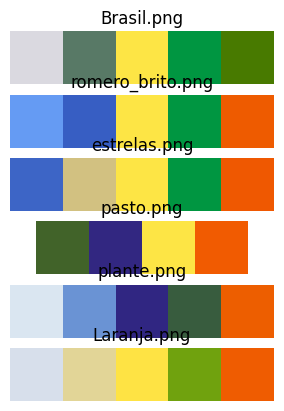

In [45]:
import matplotlib.pyplot as plt

fig = plt.figure()
for i in range(len(cores)):
    ax = fig.add_subplot(len(cores),1,i+1)

    ax.imshow([list(map(rgbaiter,cores[i]))])
    ax.axis('off')
    ax.set_title(nomes_orde[i])

In [4]:
#vou tentar pegar as imagens direto do c2v sem guarda-las pegando todos os pixels

import cv2
import os


cores_nov = []
proporcoes_nov = []
nomes_nov = []

imagens_dir= '/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/Projeto-Portinari/id_Cores/teste_das_cores_sem_quadro'

# cria uma lista com todos os caminhos
cam_imagens = [f for f in os.listdir(imagens_dir) 
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]


for idx,img in enumerate(cam_imagens):
    #juntando o nome do arquivo da imagem para o caminho do folder das imagens
    caminho_img = os.path.join(imagens_dir,img)

    imagem = cv2.imread(caminho_img)

    imagem = imagem.reshape((-1,3))

    print(imagem.shape)

    cor,qtd = cor_predominante(imagem)
    cores_nov.append(cor)
    proporcoes_nov.append(qtd)
    nomes_nov.append(img)

    
    

(3004800, 3)
(3642240, 3)
(3039360, 3)
(2712960, 3)
(2720640, 3)
(2513280, 3)
(3144960, 3)
(3571200, 3)


In [1]:
def rgbaiter(cor):
    b= cor[0]
    g= cor[1]
    r = cor[2]
    return [r,g,b]


<Figure size 640x480 with 0 Axes>

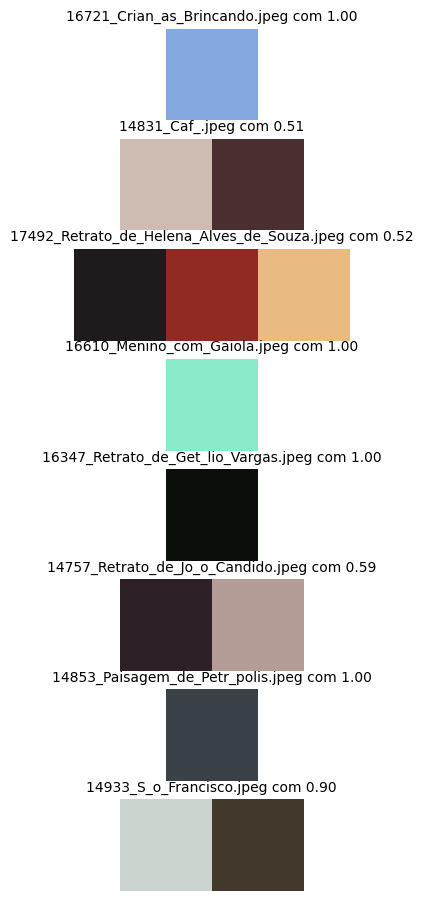

In [6]:
import matplotlib.pyplot as plt
fig = plt.figure()

altura_dinamica = 1.4 * len(cores_nov)
fig = plt.figure(figsize=(6, altura_dinamica))

for i in range(len(cores_nov)):
    ax = fig.add_subplot(len(cores_nov),1,i+1)

    ax.imshow([list(map(rgbaiter,cores_nov[i]))])
    ax.axis('off')
    ax.set_title(f'{nomes_nov[i]} com {proporcoes_nov[i]:.2f}', pad=6, fontsize=10)